In [3]:
import numpy as np
import os
from tqdm import tqdm

import matplotlib.pyplot as plt

from collections import defaultdict

In [4]:
import glob
npz = sorted(glob.glob(f'datasets/walker/rnd/buffer/*.npz'))

In [5]:
observations = []
actions = []
physics = []

dataset = defaultdict(list)

for buffer_file_path in tqdm(npz):
    # buffer_file_path = os.path.join(buffers_path, buffer_file)
    
    data = np.load(buffer_file_path)
    
    dataset['observations'].append(data['observation'][:-1])
    dataset['actions'].append(data['action'][1:])
    dataset['physics'].append(data['physics'][1:])
    terminals = np.full((len(data['observation']) - 1,), False)
    dataset['terminals'].append(terminals)
    
    # break


100%|██████████| 10000/10000 [00:25<00:00, 385.56it/s]


In [6]:
for k, v in dataset.items():
    dataset[k] = np.stack(v, axis=0)

In [7]:
np.save('datasets/walker_rnd.npy', dataset)

In [10]:
observations = dataset['observations']

In [17]:
observations.shape

(10000, 1000, 24)

In [14]:
aux_cheetah = np.load('datasets/aux_walker.npy')
aux = aux_cheetah.reshape(10000, 1000, 3)

In [15]:
def pearson_corr(x, y):
    """
    Compute the Pearson correlation between two vectors x and y.
    Inputs:
        x: numpy array of shape (d,)
        y: numpy array of shape (d,)
    Returns:
        Scalar correlation coefficient
    """
    x = np.asarray(x)
    y = np.asarray(y)

    x_centered = x - x.mean()
    y_centered = y - y.mean()

    numerator = np.dot(x_centered, y_centered)
    denominator = np.linalg.norm(x_centered) * np.linalg.norm(y_centered)

    return numerator / (denominator + 1e-8)

In [20]:
for i in range(24):
    print(i, pearson_corr(aux[..., 0].flatten(), observations[..., i].flatten()))

0 -0.03659197782531527
1 0.066466357727993
2 0.04784094495217424
3 0.08293053549163176
4 -0.04955440709384023
5 0.08035757856520248
6 -0.03127986320233926
7 0.06216839634846737
8 0.04401565771316557
9 0.08914862453908427
10 -0.06019305428350826
11 0.06401672151203935
12 -0.03733566496756177
13 0.040063064688024584
14 0.015285731740858387
15 -0.012228059557621969
16 0.6292435235721221
17 0.2265331441270122
18 -0.005714322312525357
19 0.0017151045337204665
20 -0.0044382817875657805
21 -0.005986571163620227
22 0.0015197501652200536
23 -0.0036322189478940215


In [26]:
observations[:10000, :-1, i].flatten().shape

(10000000,)

In [6]:
ids = speed_2.mean(axis=-1).argsort()[-50:]

0 0.42040628
1 9.647167
2 0.4794306
3 0.5267078
4 0.535306
5 0.3158125
6 0.568423
7 0.38047835
8 1.6492368
9 1.7846605
10 4.350988
11 11.668425
12 14.019884
13 15.308305
14 8.932672
15 14.13869
16 11.107494


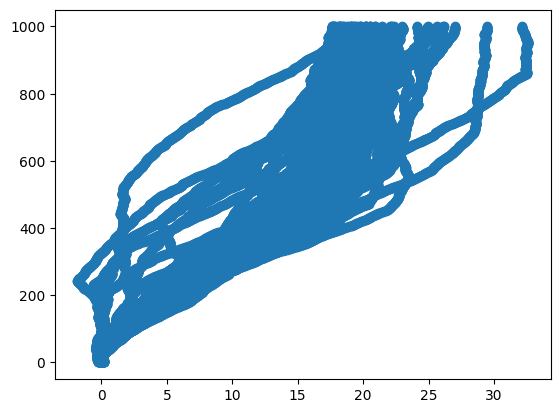

In [8]:
b = 4856


plt.scatter(physics[ids, :, 0], np.concatenate([np.arange(1001) for _ in range(50)]))

---

In [9]:
'cheetah_run'

import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('cheetah_run')
# dataset = env.get_dataset()

NameNotFound: Environment `cheetah_run` doesn't exist. Did you mean: `halfcheetah-random`?

In [8]:
_STAND_HEIGHT = 1.2
horizontal_velocity = states[..., 24:25]
torso_upright = states[..., 25:26]
torso_height = states[..., 26:27]
standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
upright = (1 + torso_upright) / 2
stand_reward = (3*standing + upright) / 4
move_reward = self.tolerance(horizontal_velocity,
                                lower=params,
                                upper=float('inf'),
                                margin=params/2,
                                value_at_margin=0.5,
                                sigmoid='linear')
# move_reward[params == 0] = stand_reward[params == 0]
rew = stand_reward * (5*move_reward + 1) / 6

In [36]:
from dm_control import suite
env = suite.load(domain_name="walker", task_name="walk")
time_step = env.reset()
obs = env.observation_spec()

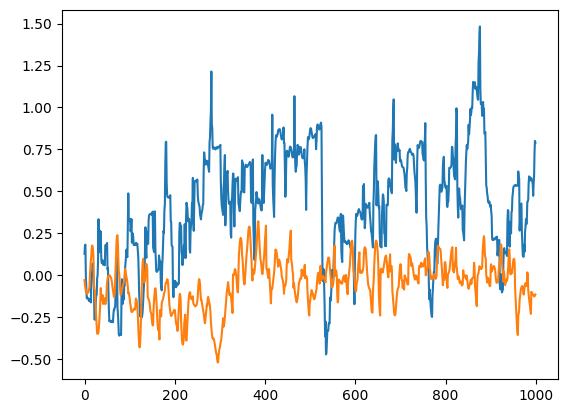

In [48]:
i = 12

plt.plot(aux_cheetah[i*1000:(i+1)*1000])

plt.plot(speed.flatten()[i*1000:(i+1)*1000])

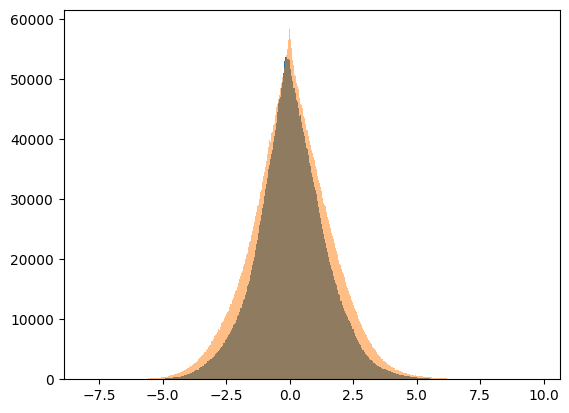

In [27]:
_ = plt.hist(aux_cheetah, bins=1000)

_ = plt.hist(speed.flatten() * 9.5, bins=1000, alpha=0.5)

In [129]:
from dm_control import suite


env = suite.load(
    domain_name='cheetah',
    task_name='run',
)

In [132]:
timestep = env.reset()
timestep.observation

OrderedDict([('position',
              array([-0.09637854,  0.03092638, -0.04088536,  0.0009259 , -0.07381088,
                      0.00759902, -0.03082418, -0.01630955])),
             ('velocity',
              array([-0.00624471, -0.00676293,  0.00892092, -0.00295232,  0.00535656,
                     -0.01260424, -0.00028743, -0.03768206, -0.04417738]))])

array([-0.09056764,  0.02781487, -0.0775037 , -0.02860264, -0.10629871,
        0.00780382, -0.00430711,  0.0079955 ,  0.07857636,  0.02382383,
       -0.04055331,  0.10434891,  0.04912331,  0.14458826,  0.000924  ,
        0.1489757 ,  0.20397179], dtype=float32)

In [142]:
physics[0, 0].shape

(18,)

In [190]:
i, j = 10, 8

with env.physics.reset_context():
    env.physics.set_state(physics[i, j])
    
timestep = env.step(actions[i, j+1])

print(timestep.observation['position'].round(3))
print(observations[i, j+1, :8].round(3))

[-0.132  0.013 -0.36  -0.38  -0.487  0.011  0.115 -0.511]
[-0.132  0.013 -0.36  -0.38  -0.487  0.011  0.115 -0.511]


array([-0.08809142,  0.03783834, -0.09494254, -0.04505788, -0.06372856,
        0.00861875, -0.02917044, -0.00260834])

array([-0.08809472,  0.03787882, -0.0950553 , -0.04504948, -0.06356186,
        0.00864573, -0.02935095, -0.0026896 ], dtype=float32)